In [2]:
import json
import ee
import pandas as pd
ee.Authenticate()
ee.Initialize(project="gen-lang-client-0412358476")

with open("../config/aoi.geojson") as f:
    aoi_points = json.load(f)

aois = {}
for nama, info in aoi_points.items():
    lon, lat = info["coord"]
    aois[nama] = ee.Geometry.Point([lon, lat]).buffer(info["buffer_m"])

print(f"Total {len(aois)} AOI dimuat")

Total 18 AOI dimuat


In [1]:
CLOUD_FILTER   = 20
CLD_PRB_THRESH = 50
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST   = 1
BUFFER         = 50


In [3]:

YEAR = 2024
AOI  = aois['Titik_01']

In [4]:
def get_s2_sr_cld_col(aoi, start_date, end_date):
    s2_sr_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', CLOUD_FILTER)))
    s2_cloudless_col = (ee.ImageCollection('COPERNICUS/S2_CLOUD_PROBABILITY')
        .filterBounds(aoi)
        .filterDate(start_date, end_date))
    return ee.ImageCollection(ee.Join.saveFirst('s2cloudless').apply(**{
        'primary': s2_sr_col,
        'secondary': s2_cloudless_col,
        'condition': ee.Filter.equals(**{
            'leftField': 'system:index', 'rightField': 'system:index'
        })
    }))

def add_cloud_bands(img):
    cld_prb = ee.Image(img.get('s2cloudless')).select('probability')
    is_cloud = cld_prb.gt(CLD_PRB_THRESH).rename('clouds')
    return img.addBands(ee.Image([cld_prb, is_cloud]))

def add_shadow_bands(img):
    not_water = img.select('SCL').neq(6)
    SR_BAND_SCALE = 1e4
    dark_pixels = img.select('B8').lt(NIR_DRK_THRESH * SR_BAND_SCALE).multiply(not_water).rename('dark_pixels')
    shadow_azimuth = ee.Number(90).subtract(ee.Number(img.get('MEAN_SOLAR_AZIMUTH_ANGLE')))
    cld_proj = (img.select('clouds').directionalDistanceTransform(shadow_azimuth, CLD_PRJ_DIST * 10)
        .reproject(**{'crs': img.select(0).projection(), 'scale': 100})
        .select('distance').mask().rename('cloud_transform'))
    shadows = cld_proj.multiply(dark_pixels).rename('shadows')
    return img.addBands(ee.Image([dark_pixels, cld_proj, shadows]))

def add_cld_shdw_mask(img):
    img_cloud = add_cloud_bands(img)
    img_cloud_shadow = add_shadow_bands(img_cloud)
    is_cld_shdw = img_cloud_shadow.select('clouds').add(img_cloud_shadow.select('shadows')).gt(0)
    is_cld_shdw = (is_cld_shdw.focalMin(2).focalMax(BUFFER * 2 / 20)
        .reproject(**{'crs': img.select([0]).projection(), 'scale': 20})
        .rename('cloudmask'))
    return img_cloud_shadow.addBands(is_cld_shdw)

def apply_cld_shdw_mask(img):
    not_cld_shdw = img.select('cloudmask').Not()
    return img.select('B.*').updateMask(not_cld_shdw)

In [5]:
def otsu(histogram):
    """Otsu threshold dari ee.Reducer.histogram — full server-side."""
    counts = ee.Array(ee.Dictionary(histogram).get('histogram'))
    means = ee.Array(ee.Dictionary(histogram).get('bucketMeans'))
    size = means.length().get([0])
    total = counts.reduce(ee.Reducer.sum(), [0]).get([0])
    sum_ = means.multiply(counts).reduce(ee.Reducer.sum(), [0]).get([0])
    mean = sum_.divide(total)

    indices = ee.List.sequence(1, size)

    def bss(i):
        a_counts = counts.slice(0, 0, i)
        a_count = a_counts.reduce(ee.Reducer.sum(), [0]).get([0])
        a_means = means.slice(0, 0, i)
        a_mean = a_means.multiply(a_counts).reduce(ee.Reducer.sum(), [0]).get([0]).divide(a_count)
        b_count = total.subtract(a_count)
        b_mean = sum_.subtract(a_count.multiply(a_mean)).divide(b_count)
        return a_count.multiply(a_mean.subtract(mean).pow(2)).add(
               b_count.multiply(b_mean.subtract(mean).pow(2)))

    bss_values = indices.map(lambda i: bss(ee.Number(i)))
    return means.sort(bss_values).get([-1])

In [6]:
def add_mndwi_resampled(img):
    """MNDWI dengan B11 di-resample bilinear ke grid 10m (native B3)
    sebelum dikombinasikan — mengurangi staircase dari alignment 10m vs 20m."""
    b3 = img.select('B3')
    b11 = (img.select('B11')
              .resample('bilinear')
              .reproject(crs=b3.projection(), scale=10))
    mndwi = b3.subtract(b11).divide(b3.add(b11)).rename('MNDWI')
    return img.addBands(mndwi)

In [7]:
def compute_water_mask(mndwi_img, threshold, closing_radius=2, scale=10):
    water = mndwi_img.select('MNDWI').gt(threshold)
    proj = mndwi_img.select('MNDWI').projection()
    cleaned = (water
               .focalMode(radius=1, kernelType='square', units='pixels')
               .focalMax(closing_radius, kernelType='square', units='pixels')
               .focalMin(closing_radius, kernelType='square', units='pixels')
               .reproject(crs=proj, scale=scale)
               .rename('water'))
    return cleaned

def extract_edge(water):
    return water.subtract(water.focalMin(1, units='pixels')).selfMask().rename('shoreline')

def edge_to_simplified_vector(edge, aoi, scale=10, max_pixels=1e9, tolerance_m=15):
    """QA visual only — bukan polyline murni, lihat catatan Track B fase 2."""
    vectors = edge.reduceToVectors(
        geometry=aoi, scale=scale, geometryType='polygon',
        maxPixels=max_pixels, eightConnected=True)
    return vectors.map(lambda f: f.simplify(tolerance_m))

In [8]:
def track_a_composite(coll, aoi, closing_radius=2):
    composite = (coll.map(add_cld_shdw_mask)
                     .map(apply_cld_shdw_mask)
                     .map(add_mndwi_resampled)
                     .median()
                     .clip(aoi))

    hist = composite.select('MNDWI').reduceRegion(
        reducer=ee.Reducer.histogram(255, 0.01),
        geometry=aoi, scale=10, maxPixels=1e9).get('MNDWI')
    threshold = otsu(hist)

    water_clean = compute_water_mask(composite, threshold, closing_radius=closing_radius, scale=10)
    edge = extract_edge(water_clean)
    edge_vector = edge_to_simplified_vector(edge, aoi, scale=10)

    return {'composite': composite, 'threshold': threshold,
            'water': water_clean, 'edge': edge, 'edge_vector': edge_vector}

In [9]:
def track_b_per_scene(coll, aoi, threshold, closing_radius=2):
    def per_scene(img):
        img_masked = apply_cld_shdw_mask(add_cld_shdw_mask(img))
        img_mndwi = add_mndwi_resampled(img_masked)
        water = compute_water_mask(img_mndwi, threshold, closing_radius=closing_radius, scale=10)
        edge = extract_edge(water)

        valid_stat = (img_masked.select('B3').mask()
                     .reduceRegion(reducer=ee.Reducer.mean(), geometry=aoi,
                                   scale=10, maxPixels=1e9))
        valid_val = valid_stat.get('B3')
        valid_pct = ee.Algorithms.If(valid_val, valid_val, 0)

        return (ee.Image.cat([water, edge])
                .clip(aoi)
                .set('valid_pct', valid_pct)
                .copyProperties(img, ['system:time_start', 'system:index']))

    scenes = coll.map(per_scene)

    ts = coll.aggregate_array('system:time_start').getInfo()
    ids = coll.aggregate_array('system:index').getInfo()
    valid_pcts = scenes.aggregate_array('valid_pct').getInfo()

    df = pd.DataFrame({'scene_id': ids,
                       'timestamp': pd.to_datetime(ts, unit='ms'),
                       'valid_pct': valid_pcts})
    return scenes, df

In [10]:
def diagnostic_pct_water(scenes, aoi, scale=10):
    def pct_water(img):
        stat = img.select('water').reduceRegion(
            reducer=ee.Reducer.mean(), geometry=aoi, scale=scale, maxPixels=1e9)
        val = stat.get('water')
        # ee.Algorithms.If: null dianggap falsy di server-side GEE,
        # jadi ini nutup baik kasus "key absent" MAUPUN "key ada tapi value null"
        safe_val = ee.Algorithms.If(val, val, 0)
        return img.set('pct_water', safe_val)
    checked = scenes.map(pct_water)
    return checked.aggregate_array('pct_water').getInfo()
def flag_outlier_scenes(df, col='pct_water', z_thresh=2.0):
    mean, std = df[col].mean(), df[col].std()
    df = df.copy()
    df['zscore'] = (df[col] - mean) / std if std > 0 else 0
    df['flag_outlier'] = df['zscore'].abs() > z_thresh
    return df

In [11]:
def orchestrate_preprocessing(aoi, year, start_md="05-01", end_md="10-31",
                               closing_radius=2, run_diagnostics=True):
    coll = get_s2_sr_cld_col(aoi, f"{year}-{start_md}", f"{year}-{end_md}")
    n = coll.size().getInfo()
    print(f"[orchestrator] {n} scene di collection {year}")

    a = track_a_composite(coll, aoi, closing_radius=closing_radius)
    t_val = a['threshold'].getInfo()
    print(f"[Jalur A] Otsu threshold = {t_val:.4f} | composite + water_clean siap")

    b_scenes, b_df = track_b_per_scene(coll, aoi, a['threshold'], closing_radius=closing_radius)
    print(f"[Jalur B] {len(b_df)} scene diproses per-scene")

    if run_diagnostics:
        pct_water = diagnostic_pct_water(b_scenes, aoi, scale=10)
        b_df['pct_water'] = pct_water
        b_df = flag_outlier_scenes(b_df, col='pct_water')
        n_flag = int(b_df['flag_outlier'].sum())
        print(f"[diagnostic 1] {n_flag} scene ke-flag outlier pct_water (|z|>2)")

        n_low_valid = int((b_df['valid_pct'] < 0.5).sum())
        print(f"[diagnostic 2] {n_low_valid} scene valid_pct < 50% (cloud/shadow >separuh AOI)")

        month_counts = b_df['timestamp'].dt.month.value_counts().sort_index()
        print(f"[diagnostic 2b] distribusi scene per bulan:\n{month_counts}")

    return {'track_a': a, 'track_b_scenes': b_scenes, 'track_b_timestamps': b_df}

In [12]:
result = orchestrate_preprocessing(AOI, YEAR)
result['track_b_timestamps'].head(10)

[orchestrator] 31 scene di collection 2024
[Jalur A] Otsu threshold = 0.0850 | composite + water_clean siap
[Jalur B] 31 scene diproses per-scene
[diagnostic 1] 2 scene ke-flag outlier pct_water (|z|>2)
[diagnostic 2] 4 scene valid_pct < 50% (cloud/shadow >separuh AOI)
[diagnostic 2b] distribusi scene per bulan:
timestamp
5     3
6     2
7     7
8     7
9     8
10    4
Name: count, dtype: int64


,scene_id,timestamp,valid_pct,pct_water,zscore,flag_outlier
0,20240502T023551_20240502T025256_T49MDP,2024-05-02 02:59:40.887,1.000000,0.477734,-0.006364,False
1,20240507T023529_20240507T025421_T49MDP,2024-05-07 02:59:38.804,0.786198,0.525744,0.379933,False
2,20240515T024551_20240515T030911_T49MDP,2024-05-15 03:09:35.954,0.725189,0.609850,1.056649,False
3,20240616T023529_20240616T025423_T49MDP,2024-06-16 02:59:40.928,0.000000,0.000000,-3.850249,True
4,20240621T023551_20240621T025648_T49MDP,2024-06-21 02:59:42.949,0.797895,0.494771,0.130719,False
5,20240714T024531_20240714T030638_T49MDP,2024-07-14 03:09:35.309,1.000000,0.527649,0.395255,False
6,20240716T023529_20240716T025424_T49MDP,2024-07-16 02:59:41.090,1.000000,0.522531,0.354074,False
7,20240719T024529_20240719T030657_T49MDP,2024-07-19 03:09:36.580,1.000000,0.531347,0.425010,False
8,20240724T024551_20240724T030651_T49MDP,2024-07-24 03:09:35.272,0.989509,0.533991,0.446286,False
9,20240726T023529_20240726T025546_T49MDP,2024-07-26 02:59:40.701,0.491657,0.549862,0.573981,False


In [13]:
import geemap

LONG = 110.4619860
LAT = -5.7972333

a = result['track_a']
sample_scene = ee.Image(result['track_b_scenes'].first())

Map = geemap.Map(center=[LAT, LONG], zoom=15)
Map.add_basemap("SATELLITE")

Map.addLayer(a['composite'], {'bands': ['B4','B3','B2'], 'min':0, 'max':2500, 'gamma':1.1},
             'A | RGB composite', True)
Map.addLayer(a['water'].selfMask(), {'palette': ['#2166ac']}, 'A | water_clean', False)
Map.addLayer(a['edge'], {'palette': ['#e31a1c']}, 'A | shoreline (composite)', True)

Map.addLayer(sample_scene.select('water').selfMask(), {'palette': ['#5aae61']},
             'B | water (1 scene)', False)
Map.addLayer(sample_scene.select('shoreline').selfMask(), {'palette': ['#ff7f00']},
             'B | shoreline (1 scene)', True)

Map.addLayer(AOI, {'color': 'yellow'}, 'AOI')
Map.addLayerControl()
Map

Map(center=[-5.7972333, 110.461986], controls=(WidgetControl(options=['position', 'transparent_bg'], position=…

In [14]:
import os

ocean_dir = "../models/tide_models/EOT20/ocean_tides"
load_dir  = "../models/tide_models/EOT20/load_tides"

ocean_files = [f for f in os.listdir(ocean_dir) if f.endswith('.nc')]
load_files  = [f for f in os.listdir(load_dir) if f.endswith('.nc')]

print(f"ocean_tides: {len(ocean_files)} file")
print(f"load_tides: {len(load_files)} file")
print(ocean_files)

ocean_tides: 17 file
load_tides: 17 file
['2N2_ocean_eot20.nc', 'J1_ocean_eot20.nc', 'K1_ocean_eot20.nc', 'K2_ocean_eot20.nc', 'M2_ocean_eot20.nc', 'M4_ocean_eot20.nc', 'MF_ocean_eot20.nc', 'MM_ocean_eot20.nc', 'N2_ocean_eot20.nc', 'O1_ocean_eot20.nc', 'P1_ocean_eot20.nc', 'Q1_ocean_eot20.nc', 'S1_ocean_eot20.nc', 'S2_ocean_eot20.nc', 'SA_ocean_eot20.nc', 'SSA_ocean_eot20.nc', 'T2_ocean_eot20.nc']


In [15]:
import h5py
print("h5py version:", h5py.version.info)

h5py version: Summary of the h5py configuration
---------------------------------

h5py    3.16.0
HDF5    2.0.0
Python  3.11.15 | packaged by conda-forge | (main, Jun 11 2026, 03:27:10) [MSC v.1944 64 bit (AMD64)]
sys.platform    win32
sys.maxsize     9223372036854775807
numpy   2.4.6
cython (built with) 3.2.4
numpy (built against) 2.4.2
HDF5 (built against) 2.0.0



In [18]:
import numpy as np
import pyTMD.compute

MODEL_DIR = "../models/tide_models"
MODEL_NAME = "EOT20"
test_lon, test_lat = 110.4588294, -5.7997667
test_time = pd.Timestamp("2024-05-02 02:59:40", tz="UTC")

tide_test = pyTMD.compute.tide_elevations(
    x=np.array([test_lon]),
    y=np.array([test_lat]),
    delta_time=np.array([test_time.to_datetime64()]),
    directory=MODEL_DIR,
    model=MODEL_NAME,
    epsg=4326,
    type='drift',
    standard='datetime'  # ini kuncinya, bukan epoch atau time
)
print(tide_test)

<xarray.DataArray (time: 1)> Size: 8B
array([0.11626912])
Coordinates:
  * time     (time) float64 8B 6.043e+04
    x        (time) float64 8B 110.5
    y        (time) float64 8B -5.8
Attributes:
    group:              z
    lineage:            ['2N2_ocean_eot20.nc', 'J1_ocean_eot20.nc', 'K1_ocean...
    source:             EOT20
    crs:                {'proj': 'longlat', 'datum': 'WGS84', 'ellps': 'WGS84...
    units:              meter
    constituents:       ['2n2', 'j1', 'k1', 'k2', 'm2', 'm4', 'mf', 'mm', 'n2...
    inferred:           ['2q1', 'sigma1', 'rho1', 'm1b', 'm1', 'chi1', 'pi1',...
    nodal_corrections:  FES


In [19]:
import numpy as np
import pyTMD.compute

def attach_tide_batch(b_df, lon, lat, model_dir, model_name="EOT20"):
    ts = b_df['timestamp']
    ts = ts.dt.tz_localize('UTC') if ts.dt.tz is None else ts
    
    tide_result = pyTMD.compute.tide_elevations(
        x=np.full(len(ts), lon),
        y=np.full(len(ts), lat),
        delta_time=ts.to_numpy(dtype='datetime64[ns]'),
        directory=model_dir,
        model=model_name,
        crs=4326,
        type='drift',
        standard='datetime'
    )
    
    b_df = b_df.copy()
    b_df['tide_height_m'] = tide_result.values
    return b_df

lon, lat = 110.4588294, -5.7997667  # Titik_01
b_df = attach_tide_batch(result['track_b_timestamps'], lon, lat, "../models/tide_models")
b_df[['scene_id', 'timestamp', 'pct_water', 'tide_height_m']]

,scene_id,timestamp,pct_water,tide_height_m
0,20240502T023551_20240502T025256_T49MDP,2024-05-02 02:59:40.887,0.477734,0.116290
1,20240507T023529_20240507T025421_T49MDP,2024-05-07 02:59:38.804,0.525744,0.094497
2,20240515T024551_20240515T030911_T49MDP,2024-05-15 03:09:35.954,0.609850,0.222895
3,20240616T023529_20240616T025423_T49MDP,2024-06-16 02:59:40.928,0.000000,0.226706
4,20240621T023551_20240621T025648_T49MDP,2024-06-21 02:59:42.949,0.494771,0.240770
5,20240714T024531_20240714T030638_T49MDP,2024-07-14 03:09:35.309,0.527649,0.264474
6,20240716T023529_20240716T025424_T49MDP,2024-07-16 02:59:41.090,0.522531,0.161781
7,20240719T024529_20240719T030657_T49MDP,2024-07-19 03:09:36.580,0.531347,0.165620
8,20240724T024551_20240724T030651_T49MDP,2024-07-24 03:09:35.272,0.533991,0.536540
9,20240726T023529_20240726T025546_T49MDP,2024-07-26 02:59:40.701,0.549862,0.472591


In [20]:
print(f"Range tide: {b_df['tide_height_m'].min():.3f} sampai {b_df['tide_height_m'].max():.3f} meter")
print(f"Std dev tide: {b_df['tide_height_m'].std():.3f} meter")

Range tide: -0.249 sampai 0.537 meter
Std dev tide: 0.193 meter


In [22]:
from scipy.stats import pearsonr

valid = b_df[~b_df['flag_outlier']]
r, p_value = pearsonr(valid['tide_height_m'], valid['pct_water'])

print(f"Pearson r: {r:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"n = {len(valid)} scene")

Pearson r: 0.379
p-value: 0.0428
n = 29 scene


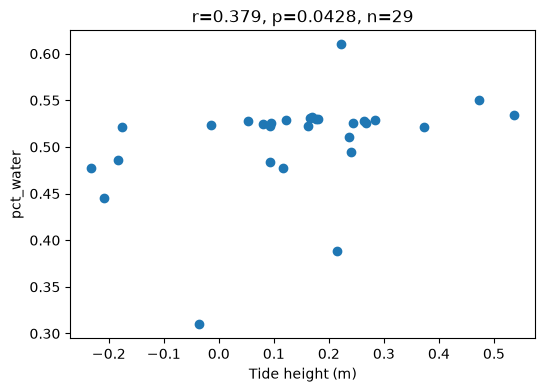

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(valid['tide_height_m'], valid['pct_water'])
plt.xlabel('Tide height (m)')
plt.ylabel('pct_water')
plt.title(f'r={r:.3f}, p={p_value:.4f}, n={len(valid)}')
plt.show()

In [24]:
from scipy.stats import pearsonr, spearmanr

# spearman: rank-based, lebih tahan outlier dibanding pearson
r_spearman, p_spearman = spearmanr(valid['tide_height_m'], valid['pct_water'])
print(f"Spearman r: {r_spearman:.3f}, p: {p_spearman:.4f}")

# cek sensitivitas: buang scene dengan pct_water paling ekstrem
robust = valid[(valid['pct_water'] > 0.4) & (valid['pct_water'] < 0.58)]
r_robust, p_robust = pearsonr(robust['tide_height_m'], robust['pct_water'])
print(f"Pearson r (tanpa outlier ekstrem): {r_robust:.3f}, p: {p_robust:.4f}, n={len(robust)}")

Spearman r: 0.511, p: 0.0046
Pearson r (tanpa outlier ekstrem): 0.623, p: 0.0007, n=26


In [25]:
import json
import numpy as np
import pandas as pd
import ee
import pyTMD.compute
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt


class ShorelinePreprocessor:
    # default constants — bisa di-override per instance
    CLOUD_FILTER   = 20
    CLD_PRB_THRESH = 50
    NIR_DRK_THRESH = 0.15
    CLD_PRJ_DIST   = 1
    BUFFER         = 50

    def __init__(self, aoi_name, lon, lat, buffer_m=1000, year=2024, closing_radius=2):
        self.aoi_name = aoi_name
        self.lon = lon
        self.lat = lat
        self.aoi = ee.Geometry.Point([lon, lat]).buffer(buffer_m)
        self.year = year
        self.closing_radius = closing_radius
        self.result = None
        self.tide_analysis = None

    def __repr__(self):
        status = "belum run" if self.result is None else "sudah run"
        tide = "" if self.tide_analysis is None else " + tide attached"
        return f"<ShorelinePreprocessor {self.aoi_name} ({self.year}) — {status}{tide}>"

    # ---------- factory: bikin banyak instance dari config ----------
    @classmethod
    def from_config(cls, config_path, year=2024, **kwargs):
        """Load semua AOI dari aoi_points.json jadi dict of instances."""
        with open(config_path) as f:
            aoi_points = json.load(f)
        instances = {}
        for nama, info in aoi_points.items():
            lon, lat = info["coord"]
            instances[nama] = cls(nama, lon, lat,
                                  buffer_m=info["buffer_m"],
                                  year=year, **kwargs)
        return instances

    # ---------- cloud/shadow masking ----------
    def _get_s2_sr_cld_col(self, start_date, end_date):
        s2_sr_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(self.aoi)
            .filterDate(start_date, end_date)
            .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', self.CLOUD_FILTER)))
        s2_cloudless_col = (ee.ImageCollection('COPERNICUS/S2_CLOUD_PROBABILITY')
            .filterBounds(self.aoi)
            .filterDate(start_date, end_date))
        return ee.ImageCollection(ee.Join.saveFirst('s2cloudless').apply(**{
            'primary': s2_sr_col, 'secondary': s2_cloudless_col,
            'condition': ee.Filter.equals(**{
                'leftField': 'system:index', 'rightField': 'system:index'})
        }))

    def _add_cloud_bands(self, img):
        cld_prb = ee.Image(img.get('s2cloudless')).select('probability')
        is_cloud = cld_prb.gt(self.CLD_PRB_THRESH).rename('clouds')
        return img.addBands(ee.Image([cld_prb, is_cloud]))

    def _add_shadow_bands(self, img):
        not_water = img.select('SCL').neq(6)
        SR_BAND_SCALE = 1e4
        dark_pixels = img.select('B8').lt(self.NIR_DRK_THRESH * SR_BAND_SCALE).multiply(not_water).rename('dark_pixels')
        shadow_azimuth = ee.Number(90).subtract(ee.Number(img.get('MEAN_SOLAR_AZIMUTH_ANGLE')))
        cld_proj = (img.select('clouds').directionalDistanceTransform(shadow_azimuth, self.CLD_PRJ_DIST * 10)
            .reproject(**{'crs': img.select(0).projection(), 'scale': 100})
            .select('distance').mask().rename('cloud_transform'))
        shadows = cld_proj.multiply(dark_pixels).rename('shadows')
        return img.addBands(ee.Image([dark_pixels, cld_proj, shadows]))

    def _add_cld_shdw_mask(self, img):
        img_cloud = self._add_cloud_bands(img)
        img_cloud_shadow = self._add_shadow_bands(img_cloud)
        is_cld_shdw = img_cloud_shadow.select('clouds').add(img_cloud_shadow.select('shadows')).gt(0)
        is_cld_shdw = (is_cld_shdw.focalMin(2).focalMax(self.BUFFER * 2 / 20)
            .reproject(**{'crs': img.select([0]).projection(), 'scale': 20})
            .rename('cloudmask'))
        return img_cloud_shadow.addBands(is_cld_shdw)

    def _apply_cld_shdw_mask(self, img):
        return img.select('B.*').updateMask(img.select('cloudmask').Not())

    # ---------- static: fungsi matematis murni ----------
    @staticmethod
    def _otsu(histogram):
        counts = ee.Array(ee.Dictionary(histogram).get('histogram'))
        means = ee.Array(ee.Dictionary(histogram).get('bucketMeans'))
        size = means.length().get([0])
        total = counts.reduce(ee.Reducer.sum(), [0]).get([0])
        sum_ = means.multiply(counts).reduce(ee.Reducer.sum(), [0]).get([0])
        mean = sum_.divide(total)
        indices = ee.List.sequence(1, size)

        def bss(i):
            a_counts = counts.slice(0, 0, i)
            a_count = a_counts.reduce(ee.Reducer.sum(), [0]).get([0])
            a_means = means.slice(0, 0, i)
            a_mean = a_means.multiply(a_counts).reduce(ee.Reducer.sum(), [0]).get([0]).divide(a_count)
            b_count = total.subtract(a_count)
            b_mean = sum_.subtract(a_count.multiply(a_mean)).divide(b_count)
            return a_count.multiply(a_mean.subtract(mean).pow(2)).add(
                   b_count.multiply(b_mean.subtract(mean).pow(2)))

        bss_values = indices.map(lambda i: bss(ee.Number(i)))
        return means.sort(bss_values).get([-1])

    @staticmethod
    def _add_mndwi_resampled(img):
        b3 = img.select('B3')
        b11 = img.select('B11').resample('bilinear').reproject(crs=b3.projection(), scale=10)
        mndwi = b3.subtract(b11).divide(b3.add(b11)).rename('MNDWI')
        return img.addBands(mndwi)

    def _compute_water_mask(self, mndwi_img, threshold, scale=10):
        water = mndwi_img.select('MNDWI').gt(threshold)
        proj = mndwi_img.select('MNDWI').projection()
        return (water
                .focalMode(radius=1, kernelType='square', units='pixels')
                .focalMax(self.closing_radius, kernelType='square', units='pixels')
                .focalMin(self.closing_radius, kernelType='square', units='pixels')
                .reproject(crs=proj, scale=scale)
                .rename('water'))

    @staticmethod
    def _extract_edge(water):
        return water.subtract(water.focalMin(1, units='pixels')).selfMask().rename('shoreline')

    # ---------- Track A ----------
    def _track_a_composite(self, coll):
        composite = (coll.map(self._add_cld_shdw_mask)
                         .map(self._apply_cld_shdw_mask)
                         .map(self._add_mndwi_resampled)
                         .median()
                         .clip(self.aoi))
        hist = composite.select('MNDWI').reduceRegion(
            reducer=ee.Reducer.histogram(255, 0.01),
            geometry=self.aoi, scale=10, maxPixels=1e9).get('MNDWI')
        threshold = self._otsu(hist)
        water_clean = self._compute_water_mask(composite, threshold)
        edge = self._extract_edge(water_clean)
        return {'composite': composite, 'threshold': threshold, 'water': water_clean, 'edge': edge}

    # ---------- Track B ----------
    def _track_b_per_scene(self, coll, threshold):
        def per_scene(img):
            img_masked = self._apply_cld_shdw_mask(self._add_cld_shdw_mask(img))
            img_mndwi = self._add_mndwi_resampled(img_masked)
            water = self._compute_water_mask(img_mndwi, threshold)
            edge = self._extract_edge(water)
            valid_stat = (img_masked.select('B3').mask()
                         .reduceRegion(reducer=ee.Reducer.mean(), geometry=self.aoi,
                                       scale=10, maxPixels=1e9))
            valid_val = valid_stat.get('B3')
            valid_pct = ee.Algorithms.If(valid_val, valid_val, 0)
            return (ee.Image.cat([water, edge]).clip(self.aoi)
                    .set('valid_pct', valid_pct)
                    .copyProperties(img, ['system:time_start', 'system:index']))

        scenes = coll.map(per_scene)
        ts = coll.aggregate_array('system:time_start').getInfo()
        ids = coll.aggregate_array('system:index').getInfo()
        valid_pcts = scenes.aggregate_array('valid_pct').getInfo()
        df = pd.DataFrame({'scene_id': ids,
                           'timestamp': pd.to_datetime(ts, unit='ms'),
                           'valid_pct': valid_pcts})
        return scenes, df

    # ---------- Diagnostics ----------
    def _diagnostic_pct_water(self, scenes, scale=10):
        def pct_water(img):
            stat = img.select('water').reduceRegion(
                reducer=ee.Reducer.mean(), geometry=self.aoi, scale=scale, maxPixels=1e9)
            val = stat.get('water')
            safe_val = ee.Algorithms.If(val, val, 0)
            return img.set('pct_water', safe_val)
        checked = scenes.map(pct_water)
        return checked.aggregate_array('pct_water').getInfo()

    @staticmethod
    def _flag_outlier_scenes(df, col='pct_water', z_thresh=2.0):
        mean, std = df[col].mean(), df[col].std()
        df = df.copy()
        df['zscore'] = (df[col] - mean) / std if std > 0 else 0
        df['flag_outlier'] = df['zscore'].abs() > z_thresh
        return df

    # ---------- TIDE: attach batch (versi yang kebukti jalan malam ini) ----------
    def attach_tide(self, model_dir, model_name="EOT20"):
        if self.result is None:
            raise RuntimeError(f"[{self.aoi_name}] Jalanin .run() dulu sebelum attach_tide()")
        b_df = self.result['track_b_timestamps']
        ts = b_df['timestamp']
        ts = ts.dt.tz_localize('UTC') if ts.dt.tz is None else ts

        tide_result = pyTMD.compute.tide_elevations(
            x=np.full(len(ts), self.lon),
            y=np.full(len(ts), self.lat),
            delta_time=ts.to_numpy(dtype='datetime64[ns]'),
            directory=model_dir,
            model=model_name,
            crs=4326,
            type='drift',
            standard='datetime'   # kunci: trigger jalur from_datetime
        )
        b_df = b_df.copy()
        b_df['tide_height_m'] = tide_result.values
        self.result['track_b_timestamps'] = b_df
        print(f"[{self.aoi_name}] tide attached | range: "
              f"{b_df['tide_height_m'].min():.3f} s/d {b_df['tide_height_m'].max():.3f} m")
        return b_df

    # ---------- TIDE: analisis perlu-tidaknya koreksi ----------
    def analyze_tide_effect(self, pct_water_bounds=(0.4, 0.58), plot=True):
        """Korelasi tide_height_m vs pct_water: Pearson, Spearman,
        dan Pearson robust (exclude pct_water ekstrem).
        pct_water_bounds default dari eksplorasi Titik_01 — sesuaikan per AOI."""
        b_df = self.result['track_b_timestamps']
        if 'tide_height_m' not in b_df.columns:
            raise RuntimeError(f"[{self.aoi_name}] attach_tide() dulu sebelum analisis")

        valid = b_df[~b_df['flag_outlier']]
        r_p, p_p = pearsonr(valid['tide_height_m'], valid['pct_water'])
        r_s, p_s = spearmanr(valid['tide_height_m'], valid['pct_water'])

        lo, hi = pct_water_bounds
        robust = valid[(valid['pct_water'] > lo) & (valid['pct_water'] < hi)]
        r_r, p_r = pearsonr(robust['tide_height_m'], robust['pct_water'])

        self.tide_analysis = {
            'pearson': (r_p, p_p, len(valid)),
            'spearman': (r_s, p_s, len(valid)),
            'pearson_robust': (r_r, p_r, len(robust)),
        }
        print(f"[{self.aoi_name}] Pearson r={r_p:.3f} (p={p_p:.4f}, n={len(valid)})")
        print(f"[{self.aoi_name}] Spearman r={r_s:.3f} (p={p_s:.4f})")
        print(f"[{self.aoi_name}] Pearson robust r={r_r:.3f} (p={p_r:.4f}, n={len(robust)})")

        if plot:
            fig, ax = plt.subplots(figsize=(6, 4))
            ax.scatter(valid['tide_height_m'], valid['pct_water'], label='valid')
            excluded = valid[~valid.index.isin(robust.index)]
            ax.scatter(excluded['tide_height_m'], excluded['pct_water'],
                       color='red', label='excluded (robust)')
            ax.set_xlabel('Tide height (m)')
            ax.set_ylabel('pct_water')
            ax.set_title(f"{self.aoi_name} | Spearman r={r_s:.3f}, p={p_s:.4f}")
            ax.legend()
            plt.show()
        return self.tide_analysis

    # ---------- Visualisasi dua jalur ----------
    def visualize(self, zoom=15):
        import geemap
        if self.result is None:
            raise RuntimeError(f"[{self.aoi_name}] Jalanin .run() dulu")
        a = self.result['track_a']
        sample_scene = ee.Image(self.result['track_b_scenes'].first())

        Map = geemap.Map(center=[self.lat, self.lon], zoom=zoom)
        Map.add_basemap("SATELLITE")
        Map.addLayer(a['composite'], {'bands': ['B4','B3','B2'], 'min':0, 'max':2500, 'gamma':1.1},
                     'A | RGB composite', True)
        Map.addLayer(a['water'].selfMask(), {'palette': ['#2166ac']}, 'A | water_clean', False)
        Map.addLayer(a['edge'], {'palette': ['#e31a1c']}, 'A | shoreline (composite)', True)
        Map.addLayer(sample_scene.select('water').selfMask(), {'palette': ['#5aae61']},
                     'B | water (1 scene)', False)
        Map.addLayer(sample_scene.select('shoreline').selfMask(), {'palette': ['#ff7f00']},
                     'B | shoreline (1 scene)', True)
        Map.addLayer(self.aoi, {'color': 'yellow'}, 'AOI')
        Map.addLayerControl()
        return Map

    # ---------- Entry point ----------
    def run(self, start_md="05-01", end_md="10-31", run_diagnostics=True):
        coll = self._get_s2_sr_cld_col(f"{self.year}-{start_md}", f"{self.year}-{end_md}")
        n = coll.size().getInfo()
        print(f"[{self.aoi_name}] {n} scene di collection {self.year}")

        a = self._track_a_composite(coll)
        t_val = a['threshold'].getInfo()
        print(f"[{self.aoi_name}] Otsu threshold = {t_val:.4f}")

        b_scenes, b_df = self._track_b_per_scene(coll, a['threshold'])
        print(f"[{self.aoi_name}] Track B: {len(b_df)} scene")

        if run_diagnostics:
            pct_water = self._diagnostic_pct_water(b_scenes)
            b_df['pct_water'] = pct_water
            b_df = self._flag_outlier_scenes(b_df)
            n_flag = int(b_df['flag_outlier'].sum())
            n_low = int((b_df['valid_pct'] < 0.5).sum())
            print(f"[{self.aoi_name}] {n_flag} outlier | {n_low} scene valid_pct<50%")

        self.result = {'track_a': a, 'track_b_scenes': b_scenes, 'track_b_timestamps': b_df}
        return self.result

[Titik_02] 31 scene di collection 2024
[Titik_02] Otsu threshold = 0.1048
[Titik_02] Track B: 31 scene
[Titik_02] 2 outlier | 2 scene valid_pct<50%
[Titik_02] tide attached | range: -0.250 s/d 0.539 m
[Titik_02] Pearson r=0.531 (p=0.0030, n=29)
[Titik_02] Spearman r=0.630 (p=0.0002)
[Titik_02] Pearson robust r=0.445 (p=0.0199, n=27)


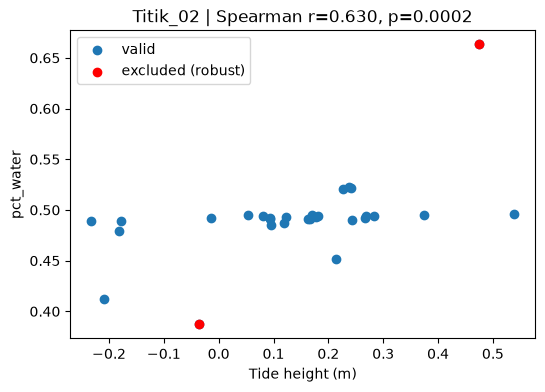

[Titik_07] 31 scene di collection 2024
[Titik_07] Otsu threshold = 0.0633
[Titik_07] Track B: 31 scene
[Titik_07] 3 outlier | 3 scene valid_pct<50%
[Titik_07] tide attached | range: -0.252 s/d 0.550 m
[Titik_07] Pearson r=0.443 (p=0.0183, n=28)
[Titik_07] Spearman r=0.352 (p=0.0663)
[Titik_07] Pearson robust r=0.791 (p=0.2094, n=4)


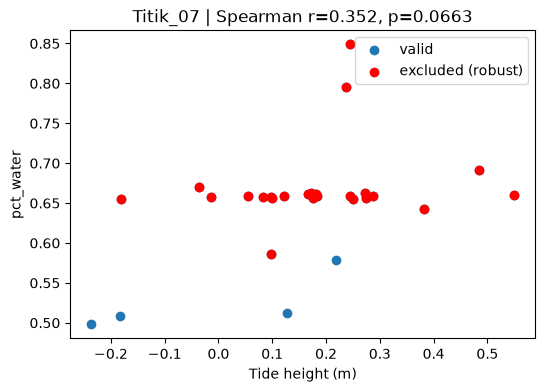

{'pearson': (np.float64(0.44291640340446325),
  np.float64(0.01825427432300354),
  28),
 'spearman': (np.float64(0.3519430760810071),
  np.float64(0.0662593365735865),
  28),
 'pearson_robust': (np.float64(0.7906164065734416),
  np.float64(0.20938359342655843),
  4)}

In [ ]:
# load semua AOI sekali
pipelines = ShorelinePreprocessor.from_config("../config/aoi.geojson", year=2024)

MODEL_DIR = "../models/tide_models"

# replikasi ke Titik_02 (erosion signal confirmed)
p2 = pipelines['Titik_02']
p2.run()
p2.attach_tide(MODEL_DIR)
p2.analyze_tide_effect()
p2.visualize()

# Titik_07 (erosion signal confirmed juga)
p7 = pipelines['Titik_07']
p7.run()
p7.attach_tide(MODEL_DIR)
p7.analyze_tide_effect()

In [27]:
p7.visualize()

Map(center=[-5.8154436, 110.4930955], controls=(WidgetControl(options=['position', 'transparent_bg'], position…

In [28]:
p2.visualize()

Map(center=[-5.7915568, 110.4666041], controls=(WidgetControl(options=['position', 'transparent_bg'], position…

[Titik_03] 31 scene di collection 2024
[Titik_03] Otsu threshold = 0.0942
[Titik_03] Track B: 31 scene
[Titik_03] 2 outlier | 2 scene valid_pct<50%
[Titik_03] tide attached | range: -0.250 s/d 0.540 m
[Titik_03] Pearson r=0.526 (p=0.0034, n=29)
[Titik_03] Spearman r=0.485 (p=0.0076)
[Titik_03] Pearson robust r=0.530 (p=0.0044, n=27)


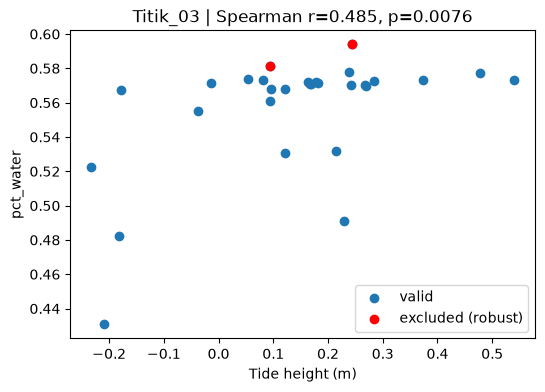

Map(center=[-5.7819511, 110.4729577], controls=(WidgetControl(options=['position', 'transparent_bg'], position…

In [29]:
p3 = pipelines['Titik_03']
p3.run()
p3.attach_tide(MODEL_DIR)
p3.analyze_tide_effect()
p3.visualize()

[Titik_04] 31 scene di collection 2024
[Titik_04] Otsu threshold = 0.0156
[Titik_04] Track B: 31 scene
[Titik_04] 2 outlier | 2 scene valid_pct<50%
[Titik_04] tide attached | range: -0.250 s/d 0.541 m
[Titik_04] Pearson r=0.469 (p=0.0103, n=29)
[Titik_04] Spearman r=0.352 (p=0.0613)
[Titik_04] Pearson robust r=0.994 (p=0.0710, n=3)


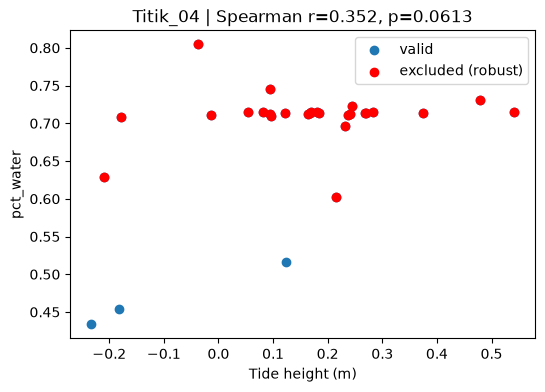

Map(center=[-5.772437, 110.4796091], controls=(WidgetControl(options=['position', 'transparent_bg'], position=…

In [30]:
p4 = pipelines['Titik_04']
p4.run()
p4.attach_tide(MODEL_DIR)
p4.analyze_tide_effect()
p4.visualize()


[Titik_06] 31 scene di collection 2024
[Titik_06] Otsu threshold = -0.0050
[Titik_06] Track B: 31 scene
[Titik_06] 3 outlier | 3 scene valid_pct<50%
[Titik_06] tide attached | range: -0.251 s/d 0.544 m
[Titik_06] Pearson r=0.532 (p=0.0036, n=28)
[Titik_06] Spearman r=0.374 (p=0.0500)
[Titik_06] Pearson robust r=0.621 (p=0.0311, n=12)


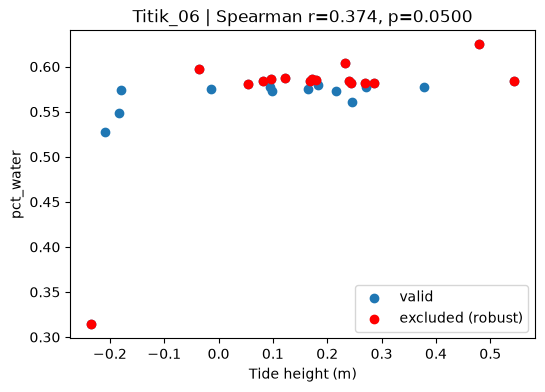

Map(center=[-5.7989676, 110.4802625], controls=(WidgetControl(options=['position', 'transparent_bg'], position…

In [32]:
p6 = pipelines['Titik_06']
p6.run()
p6.attach_tide(MODEL_DIR)
p6.analyze_tide_effect()
p6.visualize()


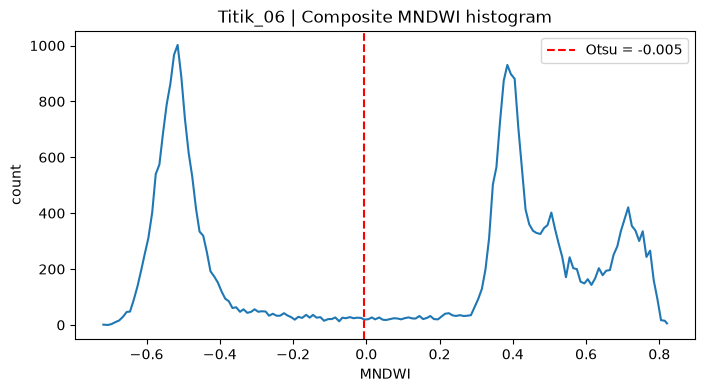

In [33]:
import matplotlib.pyplot as plt

p = pipelines['Titik_06']  # ganti sesuai AOI yang lagi dicek
a = p.result['track_a']

# hitung ulang histogram dari composite (sama persis kayak input _otsu)
hist = a['composite'].select('MNDWI').reduceRegion(
    reducer=ee.Reducer.histogram(255, 0.01),
    geometry=p.aoi, scale=10, maxPixels=1e9
).get('MNDWI').getInfo()

t_val = a['threshold'].getInfo()

plt.figure(figsize=(8, 4))
plt.plot(hist['bucketMeans'], hist['histogram'])
plt.axvline(t_val, color='red', linestyle='--', label=f'Otsu = {t_val:.3f}')
plt.xlabel('MNDWI')
plt.ylabel('count')
plt.title(f'{p.aoi_name} | Composite MNDWI histogram')
plt.legend()
plt.show()

In [34]:
def plot_scene_histograms(p, scene_ids, ncols=2):
    """Plot histogram MNDWI per-scene buat scene terpilih.
    scene_ids: list of system:index (dari b_df['scene_id'])."""
    b_df = p.result['track_b_timestamps']
    t_val = p.result['track_a']['threshold'].getInfo()

    # ambil collection sumber lagi (scene MNDWI belum kesimpen per-scene di result)
    coll = p._get_s2_sr_cld_col(f"{p.year}-05-01", f"{p.year}-10-31")

    nrows = -(-len(scene_ids) // ncols)  # ceil division
    fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 3.5*nrows))
    axes = np.atleast_1d(axes).flatten()

    for i, sid in enumerate(scene_ids):
        img = ee.Image(coll.filter(ee.Filter.eq('system:index', sid)).first())
        img_masked = p._apply_cld_shdw_mask(p._add_cld_shdw_mask(img))
        img_mndwi = p._add_mndwi_resampled(img_masked)

        hist = img_mndwi.select('MNDWI').reduceRegion(
            reducer=ee.Reducer.histogram(255, 0.01),
            geometry=p.aoi, scale=10, maxPixels=1e9
        ).get('MNDWI').getInfo()

        row = b_df[b_df['scene_id'] == sid].iloc[0]
        ax = axes[i]
        if hist is None:
            ax.set_title(f"{sid[:15]}... | NO VALID DATA")
            continue
        ax.plot(hist['bucketMeans'], hist['histogram'])
        ax.axvline(t_val, color='red', linestyle='--', label=f'Otsu(composite)={t_val:.3f}')
        ax.set_title(f"{row['timestamp'].date()} | tide={row.get('tide_height_m', float('nan')):.2f}m | pct_w={row['pct_water']:.2f}")
        ax.set_xlabel('MNDWI')
        ax.legend(fontsize=8)

    # matiin axes kosong sisa grid
    for j in range(len(scene_ids), len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

                                  scene_id               timestamp  \
27  20241009T023611_20241009T025411_T49MDP 2024-10-09 02:59:35.299   
8   20240724T024551_20240724T030651_T49MDP 2024-07-24 03:09:35.272   
16  20240818T024529_20240818T030428_T49MDP 2024-08-18 03:09:35.463   
9   20240726T023529_20240726T025546_T49MDP 2024-07-26 02:59:40.701   

    tide_height_m  pct_water  
27      -0.234137   0.313924  
8        0.543692   0.584569  
16       0.172542   0.585994  
9        0.479392   0.624551  


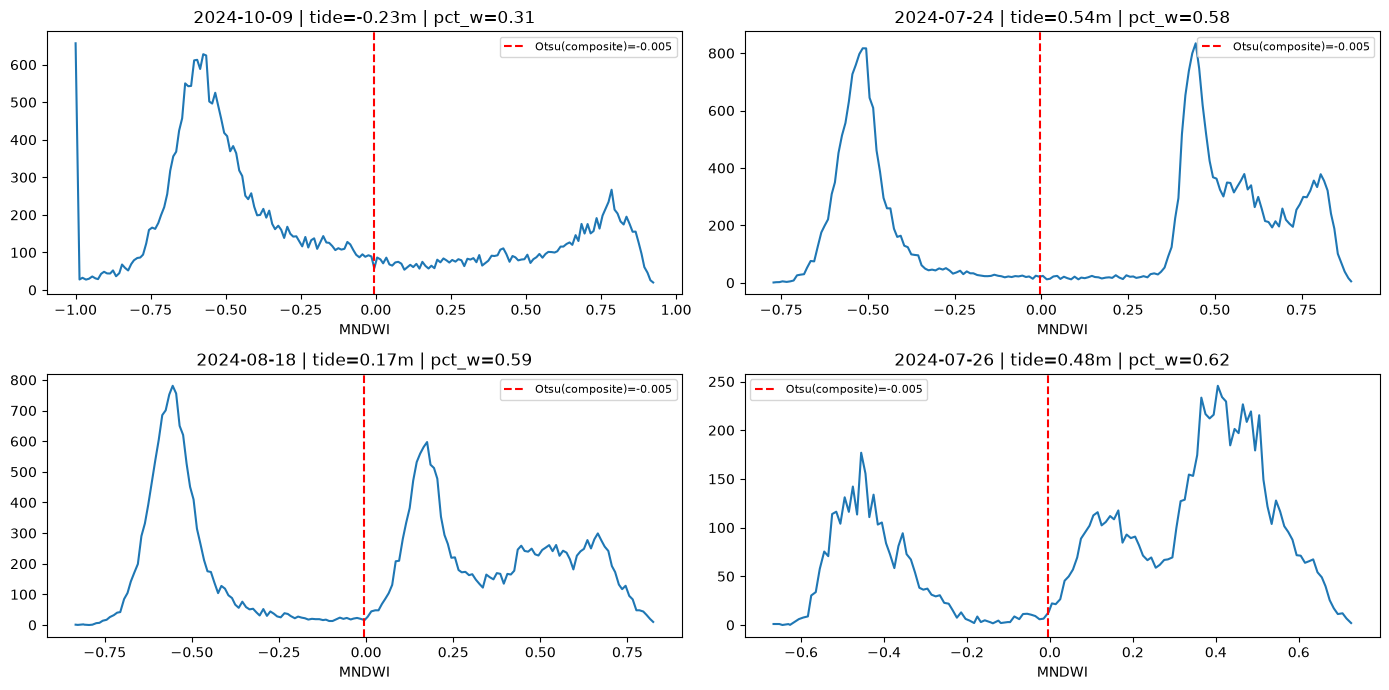

In [35]:
b_df = p.result['track_b_timestamps']
valid = b_df[~b_df['flag_outlier']].copy()

# strategi cherry-pick: ekstrem tide rendah, ekstrem tide tinggi, dan 1-2 di tengah
picks = pd.concat([
    valid.nsmallest(1, 'tide_height_m'),   # tide paling rendah
    valid.nlargest(1, 'tide_height_m'),    # tide paling tinggi
    valid.iloc[[len(valid)//2]],           # tengah-tengah
    valid.nlargest(1, 'pct_water'),        # pct_water paling ekstrem (outlier korelasi kemarin)
]).drop_duplicates('scene_id')

print(picks[['scene_id', 'timestamp', 'tide_height_m', 'pct_water']])
plot_scene_histograms(p, picks['scene_id'].tolist())

In [36]:
class ShorelinePreprocessorV2(ShorelinePreprocessor):
    """Patch v2: 
    1. Edge di-extract di extent luas, baru di-clip ke AOI yang di-erode
       (buang artefak edge palsu yang ngikutin busur lingkaran AOI)
    2. Connected-component filtering: cuma pertahankan badan air yang 
       terhubung ke laut (buang danau/tambak/kolam pedalaman)
    """

    EDGE_ERODE_M = 50          # erosi AOI biar tepi lingkaran gak jadi kandidat edge
    MIN_WATER_PIXELS = 5000    # komponen air minimal segini biar dianggap "laut"

    def _keep_ocean_only(self, water):
        """Buang komponen air yang gak nyambung ke laut.
        Asumsi: laut = komponen air TERBESAR di AOI (valid buat AOI pesisir).
        Danau/tambak/kolam = komponen kecil yang kepisah."""
        # label komponen air yang saling terhubung (8-connected)
        components = water.selfMask().connectedPixelCount(
            maxSize=1024, eightConnected=True)
        # pertahankan cuma komponen yang ukurannya >= MIN_WATER_PIXELS
        # (komponen laut selalu jauh lebih besar dari kolam pedalaman)
        ocean = water.updateMask(components.gte(self.MIN_WATER_PIXELS))
        # unmask balik jadi 0/1 penuh biar operasi downstream konsisten
        return ocean.unmask(0).rename('water')

    def _extract_edge_clean(self, water):
        """Edge extraction + clip ke AOI ter-erode, biar tepi lingkaran
        AOI gak pernah muncul sebagai garis pantai palsu."""
        edge = water.subtract(water.focalMin(1, units='pixels')).selfMask()
        inner_aoi = self.aoi.buffer(-self.EDGE_ERODE_M)
        return edge.clip(inner_aoi).rename('shoreline')

    # ---------- override Track A ----------
    def _track_a_composite(self, coll):
        composite = (coll.map(self._add_cld_shdw_mask)
                         .map(self._apply_cld_shdw_mask)
                         .map(self._add_mndwi_resampled)
                         .median()
                         .clip(self.aoi))
        hist = composite.select('MNDWI').reduceRegion(
            reducer=ee.Reducer.histogram(255, 0.01),
            geometry=self.aoi, scale=10, maxPixels=1e9).get('MNDWI')
        threshold = self._otsu(hist)

        water_raw = self._compute_water_mask(composite, threshold)
        water_ocean = self._keep_ocean_only(water_raw)          # PATCH 2
        edge = self._extract_edge_clean(water_ocean)            # PATCH 1

        return {'composite': composite, 'threshold': threshold,
                'water': water_ocean, 'water_raw': water_raw,   # raw disimpen buat debug
                'edge': edge}

    # ---------- override Track B ----------
    def _track_b_per_scene(self, coll, threshold):
        def per_scene(img):
            img_masked = self._apply_cld_shdw_mask(self._add_cld_shdw_mask(img))
            img_mndwi = self._add_mndwi_resampled(img_masked)
            water_raw = self._compute_water_mask(img_mndwi, threshold)
            water_ocean = self._keep_ocean_only(water_raw)      # PATCH 2
            edge = self._extract_edge_clean(water_ocean)        # PATCH 1

            valid_stat = (img_masked.select('B3').mask()
                         .reduceRegion(reducer=ee.Reducer.mean(), geometry=self.aoi,
                                       scale=10, maxPixels=1e9))
            valid_val = valid_stat.get('B3')
            valid_pct = ee.Algorithms.If(valid_val, valid_val, 0)

            return (ee.Image.cat([water_ocean, edge])
                    .clip(self.aoi)
                    .set('valid_pct', valid_pct)
                    .copyProperties(img, ['system:time_start', 'system:index']))

        scenes = coll.map(per_scene)
        ts = coll.aggregate_array('system:time_start').getInfo()
        ids = coll.aggregate_array('system:index').getInfo()
        valid_pcts = scenes.aggregate_array('valid_pct').getInfo()
        df = pd.DataFrame({'scene_id': ids,
                           'timestamp': pd.to_datetime(ts, unit='ms'),
                           'valid_pct': valid_pcts})
        return scenes, df

In [39]:
pipelines = ShorelinePreprocessorV2.from_config("../config/aoi.geojson", year=2024)

p3 = pipelines['Titik_03']
p3.run()
p3.visualize()   # bandingin sama screenshot tadi: busur lingkaran + kolam harusnya ilang

[Titik_03] 31 scene di collection 2024
[Titik_03] Otsu threshold = 0.0942
[Titik_03] Track B: 31 scene
[Titik_03] 0 outlier | 2 scene valid_pct<50%


Map(center=[-5.7819511, 110.4729577], controls=(WidgetControl(options=['position', 'transparent_bg'], position…

In [ ]:
import os
import numpy as np
import ee
import requests


class ShorelineDatasetBuilder:
    """Dataset construction: multi-tahun Track A water mask -> tensor ConvLSTM.

    Alur:
      1. run_years()      : jalanin preprocessing per tahun (pakai ShorelinePreprocessorV2)
      2. export_masks()   : download water mask per tahun dari GEE ke lokal (.npy)
      3. build_tensor()   : susun sliding window (sample, time, channel, H, W)
      4. temporal_split() : train/val/test kronologis buat hindcast

    Konvensi yang di-lock:
      - patch 128x128 native 10m (bukan resize ke 512 ala Boen)
      - mask biner 0/1, downloadnya nearest-equivalent (tanpa interpolasi kontinu)
      - sliding window n=3, target = frame tahun berikutnya
    """

    PATCH_SIZE = 128        # px, native 10m -> 1.28 km sisi
    WINDOW = 3              # temporal window (Boen n=3, sudah di-lock)
    SCALE = 10              # m/px

    def __init__(self, aoi_name, lon, lat, buffer_m=1000,
                 out_dir="../data/masks", preprocessor_cls=None):
        self.aoi_name = aoi_name
        self.lon = lon
        self.lat = lat
        self.buffer_m = buffer_m
        self.out_dir = os.path.join(out_dir, aoi_name)
        os.makedirs(self.out_dir, exist_ok=True)
        self.preprocessor_cls = preprocessor_cls or ShorelinePreprocessorV2
        self.preprocessors = {}   # year -> instance
        self.masks = {}           # year -> np.ndarray (H, W) binary

    # ---------- 1. preprocessing multi-tahun ----------
    def run_years(self, years, cooldown_s=10, **run_kwargs):
        """Jalanin Track A per tahun. Track B/tide gak dibutuhkan buat ConvLSTM,
        jadi run_diagnostics=False default biar hemat getInfo (rate limit)."""
        import time
        run_kwargs.setdefault('run_diagnostics', False)
        for year in years:
            if year in self.preprocessors:
                print(f"[{self.aoi_name}|{year}] sudah ada, skip")
                continue
            p = self.preprocessor_cls(self.aoi_name, self.lon, self.lat,
                                      buffer_m=self.buffer_m, year=year)
            p.run(**run_kwargs)
            self.preprocessors[year] = p
            time.sleep(cooldown_s)
        return self.preprocessors

    # ---------- 2. export mask GEE -> lokal ----------
    def export_masks(self, years=None, force=False):
        """Download water mask Track A per tahun sebagai numpy array.
        Pakai getDownloadURL (langsung, cocok buat patch kecil 128x128) —
        bukan Export.image (antrian batch, buat area besar).
        Cache ke .npy: run kedua langsung load dari disk."""
        years = years or sorted(self.preprocessors.keys())
        # region persegi PATCH_SIZE x PATCH_SIZE px, di tengah AOI
        half_m = self.PATCH_SIZE * self.SCALE / 2
        region = ee.Geometry.Point([self.lon, self.lat]).buffer(half_m).bounds()

        for year in years:
            cache_path = os.path.join(self.out_dir, f"mask_{year}.npy")
            if os.path.exists(cache_path) and not force:
                self.masks[year] = np.load(cache_path)
                print(f"[{self.aoi_name}|{year}] load dari cache")
                continue

            if year not in self.preprocessors:
                raise RuntimeError(f"Tahun {year} belum di-run. Panggil run_years dulu.")

            water = self.preprocessors[year].result['track_a']['water']
            url = water.getDownloadURL({
                'region': region,
                'scale': self.SCALE,
                'format': 'NPY',
            })
            resp = requests.get(url)
            resp.raise_for_status()
            import io
            arr = np.load(io.BytesIO(resp.content))
            # structured array dari GEE -> plain 2D binary
            mask = arr['water'].astype(np.float32)
            mask = self._enforce_patch_size(mask)
            np.save(cache_path, mask)
            self.masks[year] = mask
            print(f"[{self.aoi_name}|{year}] mask {mask.shape} tersimpan "
                  f"({mask.mean()*100:.0f}% water)")
        return self.masks

    def _enforce_patch_size(self, mask):
        """Crop/pad ke PATCH_SIZE x PATCH_SIZE persis.
        getDownloadURL kadang balikin 129x128 dll karena pembulatan region —
        crop dari tengah, pad dengan 0 kalau kurang. TANPA interpolasi
        (mask biner harus tetap 0/1)."""
        target = self.PATCH_SIZE
        h, w = mask.shape
        # crop tengah kalau kegedean
        if h > target:
            top = (h - target) // 2
            mask = mask[top:top + target, :]
        if w > target:
            left = (w - target) // 2
            mask = mask[:, left:left + target]
        # pad kalau kurang
        h, w = mask.shape
        if h < target or w < target:
            padded = np.zeros((target, target), dtype=mask.dtype)
            padded[:h, :w] = mask
            mask = padded
        return mask

    # ---------- 3. tensor sliding window ----------
    def build_tensor(self):
        """Susun (sample, time=WINDOW, channel=1, H, W) -> target (sample, 1, H, W).
        Sample dibentuk dari tahun berurutan: [t-2, t-1, t] -> predict t+1.
        Tahun harus kontinu — kalau ada gap tahun, window yang nyebrang gap di-skip."""
        years = sorted(self.masks.keys())
        if len(years) < self.WINDOW + 1:
            raise RuntimeError(f"Butuh minimal {self.WINDOW + 1} tahun, "
                               f"baru ada {len(years)}: {years}")

        X_list, y_list, meta = [], [], []
        for i in range(len(years) - self.WINDOW):
            window_years = years[i:i + self.WINDOW]
            target_year = years[i + self.WINDOW]
            # pastikan kontinu (gak nyebrang gap tahun bolong)
            expected = list(range(window_years[0], window_years[0] + self.WINDOW + 1))
            if window_years + [target_year] != expected:
                print(f"  skip window {window_years}->{target_year} (gap tahun)")
                continue
            X = np.stack([self.masks[y][np.newaxis, :, :] for y in window_years])  # (T,1,H,W)
            y_ = self.masks[target_year][np.newaxis, :, :]                          # (1,H,W)
            X_list.append(X)
            y_list.append(y_)
            meta.append({'input_years': window_years, 'target_year': target_year})

        X = np.stack(X_list)  # (N, T, 1, H, W)
        y = np.stack(y_list)  # (N, 1, H, W)
        print(f"[{self.aoi_name}] tensor: X{X.shape} y{y.shape}, "
              f"{len(meta)} sample")
        self.X, self.y, self.meta = X, y, meta
        return X, y, meta

    # ---------- 4. split temporal ----------
    def temporal_split(self, train_until=2022):
        """Split kronologis buat hindcast: sample yang target_year <= train_until
        masuk train; sisanya test. TIDAK diacak — urutan waktu = desain validasi."""
        train_idx = [i for i, m in enumerate(self.meta) if m['target_year'] <= train_until]
        test_idx  = [i for i, m in enumerate(self.meta) if m['target_year'] > train_until]

        split = {
            'X_train': self.X[train_idx], 'y_train': self.y[train_idx],
            'X_test':  self.X[test_idx],  'y_test':  self.y[test_idx],
            'meta_train': [self.meta[i] for i in train_idx],
            'meta_test':  [self.meta[i] for i in test_idx],
        }
        print(f"[{self.aoi_name}] train: {len(train_idx)} sample "
              f"(target <= {train_until}) | test: {len(test_idx)} sample")
        return split

In [ ]:
builder = ShorelineDatasetBuilder('Titik_06', 110.4802625, -5.7989676)

# 1. preprocessing 2018-2025 (Track A doang, diagnostics off — hemat rate limit)
builder.run_years(range(2018, 2026), cooldown_s=15)

# 2. download mask ke lokal (cached — run kedua instan)
builder.export_masks()

# 3. tensor sliding window
X, y, meta = builder.build_tensor()

# 4. split hindcast sesuai rencana lo
split = builder.temporal_split(train_until=2022)